Number of results in clang_axtls_transformation is 332
Number of results in clang_busybox_transformation is 4
Number of results in clang_toybox_transformation is 80
Number of results in infer_axtls_transformation is 92
Number of results in infer_busybox_transformation is 506
Number of results in infer_toybox_transformation is 103
Total number of alarms for transformation is 1008
Number of results in clang_axtls_product is 19
Number of results in clang_busybox_product is 322
Number of results in clang_toybox_product is 82
Number of results in infer_axtls_product is 16
Number of results in infer_busybox_product is 0
Number of results in infer_toybox_product is 54
Total number of alarms for product is 449
Number of results in axtls_family is 1039
Number of results in busybox_family is 940
Number of results in toybox_family is 336
Total number of alarms for family is 833
Type counts for transformation:
  uninitialized_value: 556 (55.16%)
  null_dereference: 230 (22.82%)
  dead_store: 115 (

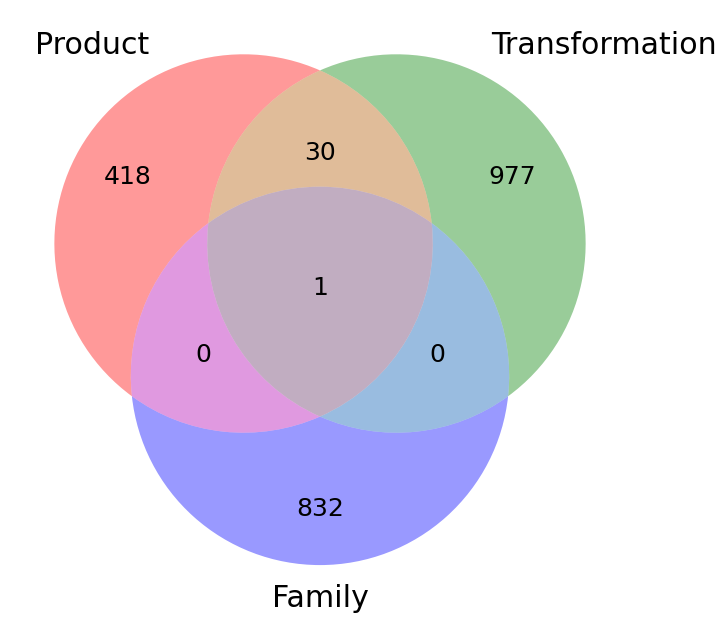

In [3]:
import os
import re
import json
from taxonomy import get_warning_type
strats: dict[str, set] = {}
for strat in ["transformation", "product", "family"]:
  strats[strat] = set()
  if strat == "transformation" or strat == "product":
    for tool in ["clang", "infer"]:
      for target in ["axtls", "busybox", "toybox"]:
        path = f"../results_rw/{tool}_{target}_{strat}/results.json"
        if os.path.exists(path):
          with open(path, 'r') as inf:
            res = json.load(inf)
            print(f"Number of results in {tool}_{target}_{strat} is {len(res)}")
            line_re = re.compile(r'line \d+')
            column_re = re.compile(r'column \d+')
            # File re to match forms like bc0ffc0e971.desugared.c:2715:1
            file_re = re.compile(r'(\w+)\.desugared\.c:\d+:\d+')
            struct_re = re.compile(r'(\w+)\_\d+')
            for r in res:
              if strat == 'product':
                fl = os.path.basename(r['originalAlarm']['fileLocation'])
                line = (r['originalAlarm']['line'], r['originalAlarm']['line'])
                typ = get_warning_type(r)
                key = (fl, line, typ)
                strats[strat].add(key)
              else:
                key = (os.path.basename(r['originalFile']), tuple(r['lineInputFile']), get_warning_type(r))
                strats[strat].add(key)
  else:
    for target in ["axtls", "busybox", "toybox"]:
      path = f"../results_rw/{target}_{strat}/results.json"
      if os.path.exists(path):
        with open(path, 'r') as inf:
          res = json.load(inf)
          print(f"Number of results in {target}_{strat} is {len(res)}")
          for r in res:
            r['strategy'] = 'family'
            key = (os.path.basename(r['input_file']), (r['line_number'], r['line_number']), get_warning_type(r))
            strats[strat].add(key)
  print(f"Total number of alarms for {strat} is {len(strats[strat])}")
  
# Count the occurrence of types emitted by each strategy
type_counts: dict[str, dict[str, int]] = {}
for strat in strats:
  type_counts[strat] = {}
  for alarm in strats[strat]:
    typ = alarm[2]
    if typ not in type_counts[strat]:
      type_counts[strat][typ] = 0
    type_counts[strat][typ] += 1

for strat in type_counts:
  print(f"Type counts for {strat}:")
  for typ, count in sorted(type_counts[strat].items(), key=lambda x: x[1], reverse=True):
    # Print type, count, and percentage of total alarms for this strategy
    percentage = (count / len(strats[strat])) * 100
    print(f"  {typ}: {count} ({percentage:.2f}%)")

from matplotlib import pyplot as plt
import matplotlib_venn
from matplotlib_venn import venn3
plt.rcParams.update({'font.size': 18})
fig, ax = plt.subplots(figsize=(8, 8))
venn3(subsets=(strats['product'],
               strats['transformation'],
               strats['family']), 
               set_labels=('Product', 'Transformation', 'Family'), 
               ax=ax, 
               layout_algorithm=matplotlib_venn.layout.venn3.DefaultLayoutAlgorithm(fixed_subset_sizes=(1,1,1,1,1,1,1)))
plt.savefig("/Users/anon/git/sugarlyzer-paper/resources/vbdb_rw.png", dpi=300, bbox_inches='tight')
plt.show()